# Laboratório - Busca em Ambientes Complexos II

---


## Ajustando ambiente

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt

## Motivação

A principal motivação para o uso da Busca em Feixe (*Local Beam Search ou LBS*) e dos Algoritmos Evolutivos é a necessidade de solucionar problemas complexos de otimização em espaços de estados muito grandes ou infinitos. Algoritmos de busca local mais simples, como o *Hill Climbing*, mantêm apenas um estado na memória e exploram um único caminho por vez, o que os torna muito vulneráveis a ficarem presos em armadilhas do espaço de busca, como os máximos locais.

Em contraste, a Busca em Feixe e os Algoritmos Evolutivos mantêm o rastreamento de **múltiplos estados simultaneamente** (frequentemente chamados de um "feixe" ou de uma população de $k$ indivíduos). Em vez de seguir uma única trajetória, o algoritmo trabalha com esse conjunto para ampliar a exploração.

O grande diferencial dessas abordagens não é a mera execução de buscas em paralelo, mas sim a **troca de informações úteis entre as linhas de busca**. No LBS, todos os sucessores dos $k$ estados atuais são gerados em conjunto, avaliados e ordenados. Em seguida, apenas os $k$ melhores globais sobrevivem para a próxima iteração. Na prática, se um estado começa a gerar sucessores excelentes, o algoritmo concentra seus recursos ali, abandonando rotas infrutíferas. É como se o estado sinalizasse aos demais: **"venham para cá, a grama é mais verde!"**.

No entanto, essa estratégia rigorosa pode destruir a diversidade da busca, pois os estados tendem a se aglomerar rapidamente em uma pequena região, transformando o processo em uma versão mais lenta do *Hill Climbing*. Para mitigar esse problema, a **Busca em Feixe Estocástica** (*Stochastic Beam Search*) seleciona os próximos estados de forma probabilística: a chance de um sucessor ser escolhido é diretamente proporcional ao seu valor de aptidão. Esse mecanismo simples favorece soluções melhores, mas sem eliminar a diversidade.

Sob essa perspectiva, a Busca em Feixe Estocástica funciona como um processo de **reprodução assexuada**, na qual um único estado ("pai") gera variantes de si mesmo para formar a próxima geração. É exatamente aqui que a biologia entra na computação.

Os **Algoritmos Genéticos (AGs)** expandem essa ideia ao inspirarem-se explicitamente na seleção natural, sendo em essência variantes diretas da Busca em Feixe Estocástica. AGs tem fundamento em três mecanismos biológicos principais: **seleção, recombinação (*crossover*) e mutação**. No processo de seleção, os indivíduos com maior aptidão (*fitness*) têm maior probabilidade de contribuir para a próxima geração. Em seguida, a recombinação introduz a reprodução sexuada, permitindo "cruzar" soluções e integrar blocos bem-sucedidos de diferentes origens (os "pais") em configurações completamente novas (os "filhos"). Por fim, a mutação aplica pequenas alterações aleatórias e independentes aos componentes do filho, o que garante a manutenção da diversidade e permite a exploração contínua de novas áreas.

## Objetivos de aprendizagem

* Compreender o funcionamento do **Local Beam Search** e o compartilhamento de informação entre múltiplos estados.
* Entender o papel do **Stochastic Beam Search** na preservação da diversidade via seleção probabilística.
* Relacionar buscas estocásticas com **Algoritmos Genéticos** e a metáfora da seleção natural.
* Dominar os principais **operadores genéticos**: seleção, recombinação e mutação.
* Avaliar os efeitos do **elitismo** na evolução da aptidão e no risco de máximos locais.
* Entender como o tamanho do torneio ($k$) controla a **pressão seletiva**.
* Reconhecer as limitações da **seleção por roleta** em populações homogêneas.
* Compreender o trade-off entre **convergência rápida e perda de diversidade**.


## Implementação

Para ilustrar os algoritmos, utilizaremos novamente o **problema das 8-Rainhas**. O objetivo é posicionar oito rainhas em um tabuleiro de xadrez 8x8 de forma que nenhuma rainha ataque outra. Isso significa que não pode haver duas rainhas na mesma linha, coluna ou diagonal. No final, iremos contabilizar quantas rainhas estão **apaziguadas**. Como ja discutido, a solução ideal é aquela em que o valor chega a `8`.

### Função de Objetivo

In [ ]:
def count_peaceful_queens(board):
    """Conta quantas rainhas nao atacam nenhuma outra rainha no tabuleiro."""
    peaceful_queens = 0
    n = len(board)

    for i in range(n):
        under_attack = False
        for j in range(n):
            if i == j:
                continue

            same_row = board[i] == board[j]
            same_diagonal = abs(i - j) == abs(board[i] - board[j])

            if same_row or same_diagonal:
                under_attack = True
                break

        if not under_attack:
            peaceful_queens += 1

    return peaceful_queens

### Função para gerar tabuleiro

In [ ]:
def generate_random_board(n_queen = 8):
    """
    Gera um tabuleiro aleatório para o problema das N-Rainhas.
    Cada rainha é colocada em uma linha aleatória em sua respectiva coluna.
    """
    return [random.randint(0, n_queen - 1) for _ in range(n_queen)]

### Função para visualizar tabuleiro

In [ ]:
def print_board(board):
    """
    Gera e exibe uma representacao visual do tabuleiro de xadrez como uma imagem.

    Args:
        board (list): Uma lista de 8 posicoes, onde o indice e a coluna
                      e o valor e a linha da rainha.
    """

    import matplotlib.pyplot as plt
    import numpy as np

    n = len(board)
    board_image = np.zeros((n, n, 3), dtype=np.uint8)

    # Define as cores dos quadrados do tabuleiro
    for i in range(n):
        for j in range(n):
            if (i + j) % 2 == 0:
                board_image[i, j] = [255, 255, 255]  # Branco
            else:
                board_image[i, j] = [169, 169, 169]  # Cinza

    plt.imshow(board_image)

    # Desenha as rainhas
    for i in range(n):
        plt.text(i, n - 1 - board[i], '♕', ha='center', va='center', fontsize=20, color='black')

    # Adiciona titulos e rotulos
    plt.title("Tabuleiro de Xadrez com 8 Rainhas")
    plt.xticks(np.arange(n))
    plt.yticks(np.arange(n), labels=np.arange(n-1, -1, -1))
    plt.gca().set_aspect('equal', adjustable='box')
    plt.show()

### Local Beam Search



O **Local Beam Search** é uma extensão do Hill Climbing que mantém `k` estados em vez de apenas um. Em cada passo, ele gera todos os sucessores de todos os `k` estados atuais e, em seguida, seleciona os `k` melhores sucessores para serem os novos estados atuais. Isso permite que o algoritmo explore múltiplas partes do espaço de busca simultaneamente, reduzindo a chance de ficar preso em um ótimo local.

In [ ]:
def local_beam_search(k, n_queens=8, max_iterations=1000):
    """
    Implementa a Busca em Feixe Local (Local Beam Search) para as N-Rainhas.
    """

    beam = [] # Produzindo feixe de busca a partir do valor de K
    for _ in range(k):
      board = generate_random_board(n_queens)
      beam.append((count_peaceful_queens(board), board))

    for _ in range(max_iterations):

        # Ordena do melhor (maior fitness) para o pior
        beam.sort(key=lambda x: x[0], reverse=True)
        best_fitness, best_board = beam[0]

        all_successors = []

        if best_fitness == n_queens:
          return best_board, best_fitness

        for _, state in beam:
            for col in range(n_queens):
                for row in range(n_queens):
                    if row != state[col]:
                        successor = list(state)
                        successor[col] = row
                        fitness = count_peaceful_queens(successor)
                        all_successors.append((fitness, successor))

        if not all_successors:
            break

        # Seleciona os k melhores globais
        all_successors.sort(key=lambda x: x[0], reverse=True)
        beam = all_successors[:k]

    beam.sort(key=lambda x: x[0], reverse=True)
    return beam[0]

<details>
<summary>Explicação</summary>

1.  `def local_beam_search(k, n_queens=8, max_iterations=1000):`
> Define a função que recebe a largura do feixe ($k$), o tamanho do tabuleiro e o limite de iterações.
2.  `beam = []`
> Inicializa uma lista vazia que armazenará os estados ativos (o "feixe") durante a busca.
3.  `for _ in range(k):`
> Inicia um ciclo para gerar a quantidade de estados iniciais definida pelo parâmetro $k$.
4.  `board = generate_random_board(n_queens)`
> Gera um tabuleiro aleatório onde cada posição representa a linha de uma rainha em sua respectiva coluna.
5.  `beam.append((count_peaceful_queens(board), board))`
> Calcula a pontuação do tabuleiro e o adiciona ao feixe como uma tupla de fitness e estado.
6.  `for _ in range(max_iterations):`
> Inicia o loop principal de busca que se repetirá até encontrar a solução ou atingir o limite de iterações.
7.  `beam.sort(key=lambda x: x[0], reverse=True)`
> Ordena os estados atuais do feixe do maior para o menor fitness para identificar os melhores candidatos.
8.  `best_fitness, best_board = beam[0]`
> Extrai o melhor estado encontrado até o momento dentro do feixe atual.
9.  `all_successors = []`
> Cria uma lista temporária para armazenar todos os vizinhos (sucessores) gerados a partir de todos os estados do feixe.
10. `if best_fitness == n_queens:`
> Verifica se o melhor estado atual atingiu o objetivo (no contexto do código, o valor ideal).
11. `return best_board, best_fitness`
> Retorna o tabuleiro solucionado e sua pontuação caso o critério de parada seja satisfeito.
12. `for _, state in beam:`
> Inicia a exploração de vizinhança para cada um dos $k$ estados contidos no feixe.
13. `for col in range(n_queens):`
> Itera por cada coluna do tabuleiro do estado que está sendo expandido.
14. `for row in range(n_queens):`
> Itera por cada linha possível para tentar reposicionar a rainha daquela coluna.
15. `if row != state[col]:`
> Filtra a posição atual da rainha para garantir que apenas novos estados sejam gerados.
16. `successor = list(state)`
> Cria uma cópia do tabuleiro atual para realizar a modificação sem alterar o original.
17. `successor[col] = row`
> Altera a posição da rainha na coluna específica para a nova linha testada.
18. `fitness = count_peaceful_queens(successor)`
> Calcula a função de avaliação ou fitness para o novo estado sucessor gerado.
19. `all_successors.append((fitness, successor))`
> Adiciona o novo vizinho e sua pontuação à lista global de sucessores candidatos.
20. `if not all_successors:`
> Verifica se a lista de sucessores está vazia, indicando que não há mais movimentos possíveis.
21. `break`
> Interrompe a busca caso não existam novos estados para explorar.
22. `all_successors.sort(key=lambda x: x[0], reverse=True)`
> Ordena todos os sucessores gerados por todos os estados do feixe de forma decrescente por fitness.
23. `beam = all_successors[:k]`
> Seleciona estritamente os $k$ melhores sucessores entre todos os gerados para formar o novo feixe da próxima iteração.
24. `beam.sort(key=lambda x: x[0], reverse=True)`
> Realiza uma ordenação final no feixe após o encerramento do loop de iterações.
25. `return beam[0]`
> Retorna o melhor resultado encontrado (tupla de fitness e estado) ao final do processo.
<details>


--- Resultados do Local Beam Search ---
Melhor Tabuleiro encontrado: [1, 4, 6, 0, 2, 7, 5, 3]
Fitness (rainhas pacíficas): 8


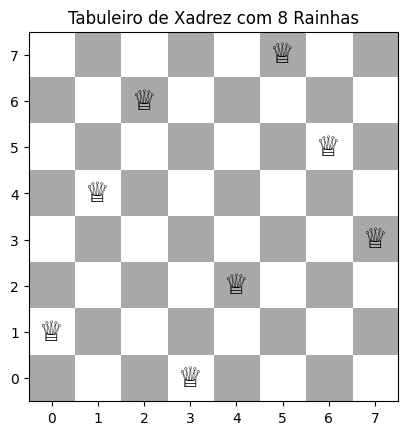

In [ ]:
best_board_lbs, best_fitness_lbs = local_beam_search(k=4, n_queens=8, max_iterations=1000)

print(f"\n--- Resultados do Local Beam Search ---")
print(f"Melhor Tabuleiro encontrado: {best_board_lbs}")
print(f"Fitness (rainhas pacíficas): {best_fitness_lbs}")

# Se uma solução foi encontrada, visualize o tabuleiro
if best_board_lbs and best_fitness_lbs == 8:
    print_board(best_board_lbs)
elif best_board_lbs:
    print(f"Não foi encontrada uma solução ótima. O melhor tabuleiro tem {best_fitness_lbs} rainhas pacíficas.")
    print_board(best_board_lbs)
else:
    print("Nenhum tabuleiro válido foi retornado.")

### Stochastic Beam Search


O Stochastic Beam Search é uma variação do Local Beam Search. Em vez de selecionar os k melhores sucessores de forma determinística, ele seleciona os k sucessores de forma estocástica (probabilística), onde a probabilidade de um sucessor ser escolhido é proporcional à sua qualidade (ou inversamente proporcional ao número de ataques, no nosso caso). Isso ajuda a evitar ótimos locais, permitindo que o algoritmo explore estados menos promissores que podem levar a soluções melhores a longo prazo.

In [ ]:
def stochastic_beam_search(k, n_queens=8, max_iterations=1000):
    """
    Adiciona o componente estocástico na Busca Local em Feixe para as N-Rainhas.
    """

    beam = []
    for _ in range(k):
      board = generate_random_board(n_queens)
      beam.append((count_peaceful_queens(board), board))

    for _ in range(max_iterations):
        beam.sort(key=lambda x: x[0], reverse=True)
        best_fitness, best_board = beam[0]

        all_successors = []

        if best_fitness == n_queens:
          return best_fitness, best_board

        for _, state in beam:
            for col in range(n_queens):
                for row in range(n_queens):
                    if row != state[col]:
                        successor = list(state)
                        successor[col] = row
                        fitness = count_peaceful_queens(successor)
                        all_successors.append((fitness, successor))

        if not all_successors:
            break

        # Extrai os valores de fitness de todos os sucessores gerados para servirem como pesos
        successors_weights = [sucessor[0] for sucessor in all_successors]
        beam = random.choices(all_successors, weights=successors_weights, k=k)

    beam.sort(key=lambda x: x[0], reverse=True)
    return beam[0]

<details>
<summary>Explicação</summary>

1.  `def stochastic_beam_search(k, n_queens=8, max_iterations=1000):`

> Define a função que implementa a busca em feixe estocástica, recebendo a largura do feixe ($k$), o número de rainhas e o limite de iterações.

2.  `beam = []`

> Inicializa uma lista vazia que servirá para armazenar o conjunto atual de estados (o feixe).

3.  `for _ in range(k):`

> Inicia um laço para criar os $k$ estados iniciais que comporão o primeiro feixe.

4.  `board = generate_random_board(n_queens)`

> Gera um tabuleiro aleatório para servir como ponto de partida para um dos caminhos do feixe.

5.  `beam.append((count_peaceful_queens(board), board))`

> Calcula a qualidade (fitness) do tabuleiro e o adiciona ao feixe como uma tupla.

6.  `for _ in range(max_iterations):`

> Inicia o loop principal de busca que será executado até encontrar a solução ou atingir o limite de iterações.

7.  `beam.sort(key=lambda x: x[0], reverse=True)`

> Ordena os estados do feixe atual de forma decrescente pelo valor de fitness para identificar o melhor candidato.

8.  `best_fitness, best_board = beam[0]`

> Armazena temporariamente o valor de fitness e o tabuleiro do melhor indivíduo do feixe atual.

9.  `all_successors = []`

> Inicializa uma lista vazia para coletar todos os vizinhos possíveis gerados a partir de cada estado do feixe.

10. `if best_fitness == n_queens:`

> Verifica se o melhor estado atual é a solução perfeita (onde todas as rainhas estão em paz).

11. `return best_fitness, best_board`

> Retorna a pontuação e o tabuleiro caso o objetivo tenha sido alcançado.

12. `for _, state in beam:`

> Itera sobre cada um dos estados presentes no feixe atual para expandir seus vizinhos.

13. `for col in range(n_queens):`

> Percorre cada coluna do tabuleiro do estado que está sendo expandido.

14. `for row in range(n_queens):`

> Testa cada linha possível daquela coluna para gerar um novo movimento.

15. `if row != state[col]:`

> Garante que a rainha seja movida para uma posição diferente da que ocupa no momento.

16. `successor = list(state)`

> Cria uma cópia independente do tabuleiro original para que a modificação não afete o estado pai.

17. `successor[col] = row`

> Aplica o movimento, alterando a linha da rainha na coluna específica do sucessor.

18. `fitness = count_peaceful_queens(successor)`

> Calcula a função de avaliação (fitness) para o novo tabuleiro gerado.

19. `all_successors.append((fitness, successor))`

> Adiciona o novo estado e sua avaliação à lista global de sucessores candidatos.

20. `if not all_successors:`

> Verifica se nenhum sucessor foi gerado, o que interromperia a busca.

21. `break`

> Sai do loop de iterações caso a vizinhança esteja vazia.

22. `successors_weights = [sucessor[0] for sucessor in all_successors]`

> Cria uma lista contendo apenas os valores de fitness de todos os sucessores para serem usados como pesos de probabilidade.

23. `beam = random.choices(all_successors, weights=successors_weights, k=k)`

> Seleciona os próximos $k$ estados aleatoriamente, onde tabuleiros com maior fitness têm maior chance de serem escolhidos.

24. `beam.sort(key=lambda x: x[0], reverse=True)`

> Ordena o feixe final uma última vez após o encerramento do processo de busca.

25. `return beam[0]`

> Retorna o melhor estado encontrado (tupla fitness e tabuleiro) ao final de todas as iterações.

</details>


--- Resultados do Stochastic Beam Search ---
Melhor Tabuleiro encontrado: [5, 3, 1, 7, 4, 6, 0, 2]
Fitness (rainhas pacíficas): 8


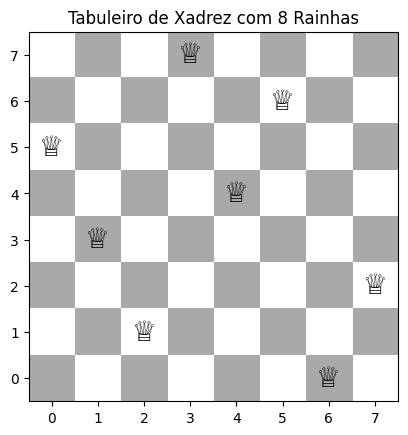

In [ ]:
best_fitness_sbs, best_board_sbs = stochastic_beam_search(k=4, n_queens=8, max_iterations=1000)

print(f"\n--- Resultados do Stochastic Beam Search ---")
print(f"Melhor Tabuleiro encontrado: {best_board_sbs}")
print(f"Fitness (rainhas pacíficas): {best_fitness_sbs}")

# Se uma solução foi encontrada, visualize o tabuleiro
if best_board_sbs and best_fitness_sbs == 8:
    print_board(best_board_sbs)
elif best_board_sbs:
    print(f"Não foi encontrada uma solução ótima. O melhor tabuleiro tem {best_fitness_sbs} rainhas pacíficas.")
    print_board(best_board_sbs)
else:
    print("Nenhum tabuleiro válido foi retornado.")

### Algoritmos Genéticos

Algoritmos Genéticos (AGs) são uma classe de algoritmos de busca adaptativos inspirados no processo de evolução natural. Eles operam em uma população de soluções candidatas (indivíduos), aplicando operadores genéticos como seleção, cruzamento (crossover) e mutação para evoluir a população ao longo de gerações. O objetivo é que as soluções "mais aptas" (aquelas que resolvem melhor o problema) sobrevivam e se reproduzam, levando a uma melhoria gradual da população.



Componentes de um Algoritmo Genético:

1.  **População Inicial**: Um conjunto de soluções geradas aleatoriamente.
2.  **Função de Aptidão (Fitness Function)**: Avalia a qualidade de cada solução. Para o problema das 8-Rainhas, quanto mais rainhas em paz maior a aptidão.
3.  **Seleção**: Escolhe indivíduos da população atual para serem pais na próxima geração, geralmente com base em sua aptidão.
4.  **Cruzamento (Crossover)**: Combina material genético de dois pais para criar um ou mais filhos.
5.  **Mutação**: Introduz pequenas alterações aleatórias nos filhos para manter a diversidade genética e evitar ótimos locais.
6.  **Critério de Parada**: Condição para encerrar o algoritmo (ex: número máximo de gerações, solução encontrada).

#### Aptidão

Para definir a função de Aptidão utilizamos a pontuação máxima de 28 porque a avaliação baseia-se no **número de pares de rainhas que não se atacam** (valor calculado pela fórmula $8 \times 7 / 2 = 28$). Tal aspecto permitirá produzir notas com maior granularidade, as quais permitem que a Seleção e a Recombinação consigam guiar a população passo a passo em direção à solução perfeita (o pico máximo).

In [ ]:
def count_non_attacking_pairs(chromosome):
    """
    Calcula a aptidão avaliando o número de pares de rainhas que não se atacam.
    Para o problema das 8-rainhas, a pontuação máxima (solução perfeita) é 28.
    """
    peaceful_pairs = 0
    n = len(chromosome)

    # Compara a rainha 'i' com as próximas rainhas 'j' (formando os pares)
    for i in range(n):
        for j in range(i + 1, n):
            # Se estão na mesma linha (mesmo valor da lista), o par se ataca
            if chromosome[i] == chromosome[j]:
                continue

            # Se estão na mesma diagonal (diferença de linhas == diferença de colunas)
            if abs(chromosome[i] - chromosome[j]) == abs(i - j):
                continue

            # Se passou pelos dois testes acima, não se atacam. É um par pacífico!
            peaceful_pairs += 1

    return peaceful_pairs

#### Seleção

A Seleção é o estágio onde o algoritmo implementa o princípio da Otimização. Seu objetivo computacional é garantir que os indivíduos com maior aptidão (fitness) tenham maior probabilidade de serem escolhidos como pais. Ao favorecer a sobrevivência e reprodução das melhores soluções atuais, a Seleção direciona o algoritmo para regiões mais promissoras do espaço de busca, aumentando o fitness médio da população a cada geração.

##### Método da Roleta (*Roulette Wheel Selection*)

A Seleção por Roleta é um método clássico onde a probabilidade de um indivíduo ser escolhido para compor a próxima geração é diretamente proporcional à sua pontuação de aptidão (*fitness*). Este método espelha o princípio fundamental da seleção natural: quanto melhor um indivíduo se adapta ao ambiente, maior é a sua chance de se reproduzir. Imagine uma roleta de cassino onde cada fatia representa um indivíduo da população atual.

O processo para escolher um único pai funciona da seguinte maneira:

1. **Cálculo da Aptidão Total:** Primeiramente, é calculada a soma do *fitness* de todos os indivíduos da população. Esta soma representa o perímetro total da roleta.
2. **Definição das Fatias:** Cada indivíduo recebe uma "fatia" na roleta. O tamanho dessa fatia é estritamente proporcional ao seu *fitness* individual em relação ao *fitness* total da população. Consequentemente, indivíduos mais aptos possuem fatias maiores.
3. **O Giro:** Um número aleatório é sorteado no intervalo de 0 até o valor do *fitness* total. Este número simula o local exato onde o ponteiro da roleta irá parar.
4. **A Escolha:** A roleta é percorrida (somando-se o *fitness* de cada indivíduo sequencialmente) até que a soma acumulada atinja ou ultrapasse o número sorteado. O indivíduo no qual esse limite é atingido torna-se o pai selecionado para a próxima etapa de evolução, a recombinação (*crossover*).

In [ ]:
def select_parent_roulette(population, fitness_function = count_non_attacking_pairs):
    """
    Seleção por Roleta. A probabilidade de seleção é proporcional ao fitness.
    """
    # Calcular todos os fitnesses
    fitnesses = [fitness_function(chromosome) for chromosome in population]
    total_fitness = sum(fitnesses)

    # Se o fitness total for zero, selecione aleatoriamente para evitar divisão por zero
    if total_fitness == 0:
        return random.choice(population)

    # Sortear um número aleatório (ponto na roleta)
    r = random.uniform(0, total_fitness)

    # Encontrar o indivíduo correspondente
    cumulative_sum = 0
    for i in range(len(population)):
        cumulative_sum += fitnesses[i]
        # Se a soma acumulada atingir ou passar o ponto r, este é o indivíduo selecionado
        if cumulative_sum >= r:
            return population[i]

    # Caso de erro (deve ser o último indivíduo)
    return population[-1]

<details>
  <summary>Explicação</summary>

O objetivo do método da **Roleta (Roulette Wheel Selection)** é garantir que a probabilidade de um indivíduo ser selecionado seja proporcional à sua **aptidão (*fitness*)**. Em outras palavras, quanto maior o *fitness*, maior a chance de seleção.

Considere uma população com 4 indivíduos:

| Indivíduo | Fitness |
| :-------: | :-----: |
|   **A**   |    10   |
|   **B**   |    5    |
|   **C**   |    2    |
|   **D**   |    3    |
| **Total** |  **20** |

O *fitness* total é **20**, que representa toda a roleta. Assim, cada indivíduo ocupa uma fração proporcional:

* **A:** 10/20 (50%)
* **B:** 5/20 (25%)
* **C:** 2/20 (10%)
* **D:** 3/20 (15%)

O algoritmo simula o giro da roleta sorteando um número aleatório $R$ entre 0 e 20. Suponha que $R = 12$. O algoritmo percorre os indivíduos acumulando seus *fitness* até ultrapassar esse valor:

1. Início. A soma acumulada é igual a 0
2. A: soma = 10 → ainda menor que 12 → o processo continua
3. B: soma = 10 + 5 = 15 → agora ≥ 12 → o processo para

O indivíduo **B** é selecionado. Uma vez que, o valor sorteado ($R = 12$) caiu na faixa correspondente ao indivíduo B. Se $R = 8$, a seleção ocorreria em A. Se $R = 19$, ocorreria em D.

Esse método garante que indivíduos mais aptos tenham maior probabilidade de serem escolhidos, sem eliminar completamente os menos aptos. Trata-se de um processo probabilístico proporcional ao *fitness*.

</details>

##### Método do Torneio (*Tournament Selection*)

Por outro lado, a Seleção por Torneio não exige a avaliação da aptidão total da população nem a divisão do espaço em fatias proporcionais de probabilidade. Em vez de submeter todos os indivíduos a um sorteio global e simultâneo, **essa alternativa introduz o acaso ao sortear aleatoriamente apenas uma pequena amostra da população para competir entre si**. Imagine um pequeno campeonato ocorrendo dentro da população.

O processo para escolher um único pai é o seguinte:

1. **Escolha do Tamanho ($k$):** Você define um parâmetro $k$, que representa o tamanho do torneio. Este é o número restrito de indivíduos que competirão em cada rodada.
2. **Amostragem Aleatória:** $n$ indivíduos são selecionados de forma totalmente aleatória da população atual.
3. **Competição:** A aptidão (*fitness*) de cada um desses $n$ competidores sorteados é calculada e comparada.
4. **O Vencedor:** O indivíduo com o melhor *fitness* (a maior aptidão) entre os selecionados é declarado o vencedor. Este vencedor é escolhido como o pai que irá fornecer seus "genes" para a próxima fase, a recombinação (*crossover*).

In [ ]:
def select_parent_tournament(population, fitness_function = count_non_attacking_pairs, k_tournament=10):
    """
    Seleção por Torneio genérica. Escolhe o melhor entre 'k_tournament' indivíduos.
    """
    # Sorteia k indivíduos da população
    tournament = random.sample(population, k_tournament)

    # Acha o indivíduo (pai) com maior fitness
    best_parent = max(tournament, key=fitness_function)
    return best_parent

<details>
  <summary>
    Explicação
  </summary>

O método de **Seleção por Torneio** consiste em escolher aleatoriamente um pequeno grupo de indivíduos da população e selecionar, entre eles, aquele com maior aptidão (*fitness*). Suponha que queremos selecionar um indivíduo e definimos o tamanho do torneio como $k = 3$. O algoritmo sorteia aleatoriamente três indivíduos (A, Z e F) para competir:

| Indivíduo Sorteado | Aptidão (*Fitness*) |
| :----------------: | :-----------------: |
|        **A**       |          15         |
|        **Z**       |          8          |
|        **F**       |        **22**       |
|    **Resultado**   |   **Vencedor: F**   |

Nesse caso, o indivíduo **F**, que possui o maior *fitness* (22), vence o torneio e é selecionado como pai. Esse processo é repetido — isto é, novos grupos de $k$ indivíduos são sorteados e novos torneios são realizados — até que a quantidade desejada de pais seja obtida.

A principal ideia por trás do método é simples: a seleção ocorre localmente, dentro de pequenos grupos. O parâmetro $k$ controla a pressão seletiva do algoritmo. Valores maiores de $k$ aumentam a chance de indivíduos mais aptos serem escolhidos, enquanto valores menores tornam o processo mais aleatório.

</details>


#### Função para selecionar métodos

In [ ]:
def selection(population, fitness_function = count_non_attacking_pairs, method="roulette", k_tournament=10):
    """
    Seleciona um indivíduo (pai) da população atual para reprodução.
    """
    if method == "roulette":
        # Chama a função de roleta
        return select_parent_roulette(population, fitness_function)

    elif method == "tournament":
        # Chama a função de torneio passando a população e o tamanho do torneio (k)
        return select_parent_tournament(population, fitness_function, k_tournament)

    else:
        raise ValueError("Método inválido. Escolha 'roulette' ou 'tournament'.")

#### Recombinação

A Recombinação é o principal motor da exploração eficiente. O objetivo é combinar características de dois pais para gerar novos indivíduos, permitindo que o algoritmo teste novas soluções que herdam as "boas partes" de dois indivíduos distintos. Esta troca de material genético possibilita grandes saltos no espaço de busca e acelera a convergência ao unir blocos de soluções de alta qualidade.

In [ ]:
def recombination(parent1, parent2):
    """
    Recombinação de Ponto Único (Single-Point Crossover).
    Combina dois pais para gerar dois novos descendentes.
    """
    chrom_length = len(parent1)

    # Garante que o ponto de corte não seja nas extremidades
    cut_point = random.randint(1, chrom_length - 1)

    # Gera os dois filhos combinando as partes
    child1 = parent1[:cut_point] + parent2[cut_point:]
    child2 = parent2[:cut_point] + parent1[cut_point:]

    return child1, child2

<details>
  <summary>Como a Recombinação acelera a convergência nos Algoritmos Genéticos e qual é a condição para que ela realmente funcione?</summary>

Convergência é o processo no qual, após várias gerações, a população se torna cada vez menos diversa. Nesse momento, a busca para de dar grandes saltos e passa a dar passos muito menores, pois as soluções se estabilizaram em torno de um pico de aptidão (solução ideal). A Recombinação acelera a convergência porque permite que o algoritmo dê saltos largos no espaço de busca logo no início, combinando "blocos" com funções úteis que foram descobertos por pais diferentes. No entanto, para funcionar, a estrutura genética do problema deve ser bem elaborada: os blocos de genes precisam representar componentes consistentes e úteis da vida real. Se os genes misturados forem totalmente não relacionados, o cruzamento não trará vantagem alguma.

</details>

#### Mutação

A Mutação é o mecanismo de segurança que garante a **diversidade** e evita a estagnação. Seu objetivo é introduzir pequenas alterações aleatórias no código genético (cromossomo) dos filhos. Essa variabilidade é crucial para que o algoritmo não se prenda a um ótimo local (local optimum), garantindo que novas áreas do espaço de busca possam ser testadas e que o AG consiga, eventualmente, encontrar o ótimo global.

In [ ]:
def mutation(chromosome, mutation_rate):
    """
    Mutação: Altera o valor (linha) de um gene (coluna) aleatoriamente.
    """
    new_chromosome = list(chromosome)
    chrom_length = len(new_chromosome)

    for i in range(chrom_length):
        if random.random() < mutation_rate:
            # Altera o valor da linha para outro número aleatório entre 0 e N-1
            new_chromosome[i] = random.randint(0, chrom_length - 1)
    return new_chromosome

#### Função para executar AG Básico

In [ ]:
def running_genetic_algorithm(n_queens=8, population_size=100, max_generations=1000,
                      mutation_rate=0.1, selection_method="tournament", k_tournament=5, use_elitism = False):
    """
    Executa o Algoritmo Genético de ponta a ponta em uma única função unificada.
    """
    # Gera a população inicial aleatoriamente
    population = [[random.randint(0, n_queens - 1) for _ in range(n_queens)] for _ in range(population_size)]

    print(f"--- Iniciando GA: Seleção={selection_method.upper()} | Mutação={mutation_rate} | Elitismo={use_elitism}---")

    # Ciclo de Gerações (Repete até que o critério de parada seja atingido)
    for generation in range(max_generations):
        # Avalia o melhor indivíduo da geração atual
        best_individual = max(population, key=count_non_attacking_pairs)
        best_fitness = count_non_attacking_pairs(best_individual)

        # Condição de Sucesso: se o indivíduo for "apto o suficiente" (28 pares não atacantes)
        if best_fitness == 28:
            print(f"Solução perfeita (28/28) encontrada na Geração {generation}!")
            print(f"Indivíduo (Tabuleiro): {best_individual}\n")
            return best_individual, best_fitness, generation

        if generation % 50 == 0:
            print(f"Geração {generation:03d} | Melhor Fitness atual: {best_fitness}/28")

        # Produz uma nova geração
        new_population = []

        # Aplica o Elitismo APENAS se o parâmetro estiver ativado
        if use_elitism:
            new_population.append(list(best_individual))

        # Cria a prole até atingir o tamanho máximo da população
        while len(new_population) < population_size:
            # Passo A: Seleciona dois pais da população atual
            parent1 = selection(population, count_non_attacking_pairs, method=selection_method, k_tournament=k_tournament)
            parent2 = selection(population, count_non_attacking_pairs, method=selection_method, k_tournament=k_tournament)

            # Passo B: Recombinação (cruzamento das partes para formar descendentes)
            child1, child2 = recombination(parent1, parent2)

            # Passo C: Aplica a mutação aleatória aos descendentes gerados
            child1 = mutation(child1, mutation_rate)
            child2 = mutation(child2, mutation_rate)

            # Adiciona os novos descendentes à nova população
            new_population.extend([child1, child2])

        # Ajuste Final e substituição: A antiga população é substituída pela nova
        population = new_population[:population_size]

    # Retorna o melhor indivíduo caso o limite de tempo (gerações) se esgote
    best_individual = max(population, key=count_non_attacking_pairs)
    best_fitness = count_non_attacking_pairs(best_individual)

    print(f"Máximo de {max_generations} gerações atingido sem solução perfeita.")
    print(f"Preso no Máximo Local com fitness: {best_fitness}/28")
    print(f"Indivíduo (Tabuleiro): {best_individual}\n")

    return best_individual, best_fitness, max_generations


<details>
<summary>Explicação</summary>

1.  `def running_genetic_algorithm(n_queens=8, population_size=100, max_generations=1000, mutation_rate=0.1, selection_method="tournament", k_tournament=5, use_elitism = False):`

> Define a função mestre que gerencia todo o ciclo de vida do algoritmo genético, desde a criação inicial até a convergência ou esgotamento de tempo.

2.  `population = [[random.randint(0, n_queens - 1) for _ in range(n_queens)] for _ in range(population_size)]`

> Cria a primeira geração de indivíduos de forma totalmente aleatória, onde cada número na lista representa a posição de uma rainha.

3.  `for generation in range(max_generations):`

> Inicia o laço de evolução que se repetirá por um número determinado de gerações para tentar evoluir a população.

4.  `best_individual = max(population, key=count_non_attacking_pairs)`

> Analisa toda a população atual para identificar qual indivíduo possui o maior número de pares de rainhas que não se atacam.

5.  `best_fitness = count_non_attacking_pairs(best_individual)`

> Armazena o valor numérico da qualidade (fitness) do melhor indivíduo da geração presente.

6.  `if best_fitness == 28:`

> Verifica se a solução perfeita foi encontrada (em um tabuleiro de 8 rainhas, 28 é o número máximo de pares sem conflito).

7.  `return best_individual, best_fitness, generation`

> Finaliza o algoritmo precocemente e retorna o tabuleiro vencedor, sua pontuação e em qual geração ele surgiu.

8.  `if generation % 50 == 0:`

> Condição lógica para reduzir a verbosidade no terminal, imprimindo o progresso apenas a cada 50 gerações.

9.  `new_population = []`

> Cria um recipiente vazio para armazenar os novos indivíduos que formarão a próxima geração.

10. `if use_elitism:`

> Verifica se a estratégia de elitismo está ativada nos parâmetros da função.

11. `new_population.append(list(best_individual))`

> Garante que o melhor indivíduo da geração anterior sobreviva intacto para a próxima, evitando a perda acidental da melhor solução.

12. `while len(new_population) < population_size:`

> Mantém o ciclo de reprodução ativo até que a nova população tenha o mesmo tamanho que a anterior.

13. `parent1 = selection(population, count_non_attacking_pairs, method=selection_method, k_tournament=k_tournament)`

> Escolhe o primeiro pai utilizando o critério selecionado (torneio ou roleta), favorecendo indivíduos mais aptos.

14. `parent2 = selection(population, count_non_attacking_pairs, method=selection_method, k_tournament=k_tournament)`

> Escolhe o segundo pai de forma independente para realizar o cruzamento genético.

15. `child1, child2 = recombination(parent1, parent2)`

> Executa o crossover, misturando os genes dos pais para criar dois novos descendentes com características combinadas.

16. `child1 = mutation(child1, mutation_rate)`

> Aplica uma chance de mutação aleatória no primeiro filho para introduzir diversidade e evitar estagnação.

17. `child2 = mutation(child2, mutation_rate)`

> Aplica o mesmo processo de mutação no segundo filho.

18. `new_population.extend([child1, child2])`

> Insere os dois descendentes gerados na lista que compõe a futura geração.

19. `population = new_population[:population_size]`

> Atualiza a população principal com a nova leva de indivíduos, realizando um corte caso o tamanho exceda o limite.

20. `best_individual = max(population, key=count_non_attacking_pairs)`

> Após o fim das gerações, realiza uma busca final para encontrar o melhor indivíduo sobrevivente.

21. `return best_individual, best_fitness, max_generations`

> Retorna o estado mais próximo da solução que o algoritmo conseguiu alcançar após esgotar o limite de tentativas.

<details\>

<details>
  <summary>Qual é a função do elitismo em um Algoritmo Genético?</summary>

O elitismo é a prática de incluir alguns dos pais com as melhores pontuações da geração anterior na composição da próxima geração. Sua principal função é garantir que a aptidão geral (*fitness*) da população nunca diminua com o passar do tempo, protegendo as melhores soluções já encontradas de serem perdidas.

</details>

## Exemplo prático

### Cenário 1: A Busca Sem Rumo

Para iniciarmos os testes, definiremos uma configuração inicial baseada no método de seleção por Roleta com parâmetros de mutação padrão e ausência de elitismo. Aqui, a probabilidade de um indivíduo ser escolhido como progenitor é proporcional à sua desvantagem, mas não há garantias de que os membros mais aptos da geração atual sobrevivam para a próxima iteração.

--- Iniciando GA: Seleção=ROULETTE | Mutação=0.1 | Elitismo=False---
Geração 000 | Melhor Fitness atual: 26/28
Geração 050 | Melhor Fitness atual: 26/28
Geração 100 | Melhor Fitness atual: 25/28
Geração 150 | Melhor Fitness atual: 24/28
Geração 200 | Melhor Fitness atual: 25/28
Geração 250 | Melhor Fitness atual: 24/28
Geração 300 | Melhor Fitness atual: 24/28
Geração 350 | Melhor Fitness atual: 25/28
Geração 400 | Melhor Fitness atual: 25/28
Geração 450 | Melhor Fitness atual: 26/28
Geração 500 | Melhor Fitness atual: 25/28
Geração 550 | Melhor Fitness atual: 25/28
Geração 600 | Melhor Fitness atual: 25/28
Geração 650 | Melhor Fitness atual: 26/28
Geração 700 | Melhor Fitness atual: 26/28
Geração 750 | Melhor Fitness atual: 26/28
Geração 800 | Melhor Fitness atual: 26/28
Geração 850 | Melhor Fitness atual: 26/28
Geração 900 | Melhor Fitness atual: 27/28
Geração 950 | Melhor Fitness atual: 25/28
Máximo de 1000 gerações atingido sem solução perfeita.
Preso no Máximo Local com fitness: 2

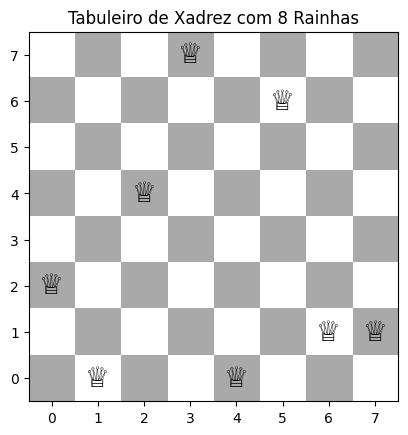

In [ ]:
best_board_ga, best_fitness_ga, generation = running_genetic_algorithm(
    n_queens=8,
    population_size=100,
    max_generations=1000,
    mutation_rate=0.1,
    selection_method="roulette",
    use_elitism=False,
    k_tournament=5
  )

print_board(best_board_ga)

### Cenário 2 - Aumento na taxa mutacional

Nesta etapa, elevamos a taxa de mutação a níveis extremos. O objetivo é observar o comportamento do algoritmo quando alterações aleatórias são aplicadas a uma vasta parcela dos descendentes em cada ciclo, testando a capacidade de exploração global do espaço de busca.

--- Iniciando GA: Seleção=ROULETTE | Mutação=0.5 | Elitismo=False---
Geração 000 | Melhor Fitness atual: 24/28
Geração 050 | Melhor Fitness atual: 24/28
Geração 100 | Melhor Fitness atual: 25/28
Solução perfeita (28/28) encontrada na Geração 108!
Indivíduo (Tabuleiro): [3, 1, 4, 7, 5, 0, 2, 6]



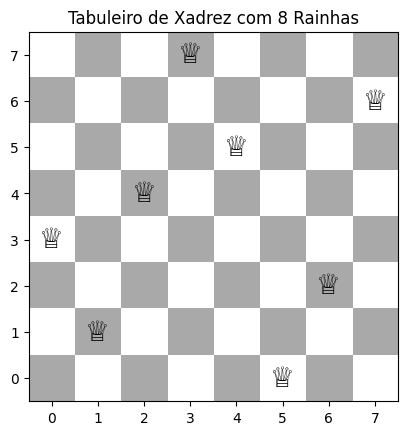

In [ ]:
best_board_ga, best_fitness_ga, generation = running_genetic_algorithm(
    n_queens=8,
    population_size=100,
    max_generations=1000,
    mutation_rate=0.5,
    selection_method="roulette",
    use_elitism=False,
    k_tournament=5
  )

print_board(best_board_ga)

<details>
  <summary>Como a mutação de 0.5 ajudou a escapar do máximo local?</summary>

A taxa de mutação determina a probabilidade e a frequência com que o material que compõe a representação dos descendentes sofre alterações aleatórias. Como analisamos no nosso histórico de chat durante o Cenário 3, a taxa extrema de 0.5 (50% de chance de mudança) operou como uma "força bruta", injetando níveis caóticos de variação na população. Na teoria, ao adicionar essa forte aleatoriedade à busca, o algoritmo consegue realizar grandes "saltos" pelo espaço de busca em vez de apenas subir em direção ao topo mais próximo. Foi esse movimento errático e agressivo que sacudiu as peças do tabuleiro até tirar a solução do aprisionamento imposto pelo máximo local.

</details>

### Cenário 3 - Com Eletismo


Neste experimento, iremos combinar uma mutação elevada com a técnica de elitismo. Ao preservar obrigatoriamente os indivíduos de maior pontuação na transição de gerações, asseguramos que o melhor fitness alcançado pelo sistema seja mantido, impedindo retrocessos na evolução da solução.

--- Iniciando GA: Seleção=ROULETTE | Mutação=0.8 | Elitismo=True---
Geração 000 | Melhor Fitness atual: 25/28
Geração 050 | Melhor Fitness atual: 27/28
Geração 100 | Melhor Fitness atual: 27/28
Geração 150 | Melhor Fitness atual: 27/28
Geração 200 | Melhor Fitness atual: 27/28
Geração 250 | Melhor Fitness atual: 27/28
Geração 300 | Melhor Fitness atual: 27/28
Geração 350 | Melhor Fitness atual: 27/28
Geração 400 | Melhor Fitness atual: 27/28
Geração 450 | Melhor Fitness atual: 27/28
Geração 500 | Melhor Fitness atual: 27/28
Geração 550 | Melhor Fitness atual: 27/28
Geração 600 | Melhor Fitness atual: 27/28
Geração 650 | Melhor Fitness atual: 27/28
Geração 700 | Melhor Fitness atual: 27/28
Geração 750 | Melhor Fitness atual: 27/28
Geração 800 | Melhor Fitness atual: 27/28
Geração 850 | Melhor Fitness atual: 27/28
Geração 900 | Melhor Fitness atual: 27/28
Geração 950 | Melhor Fitness atual: 27/28
Máximo de 1000 gerações atingido sem solução perfeita.
Preso no Máximo Local com fitness: 27

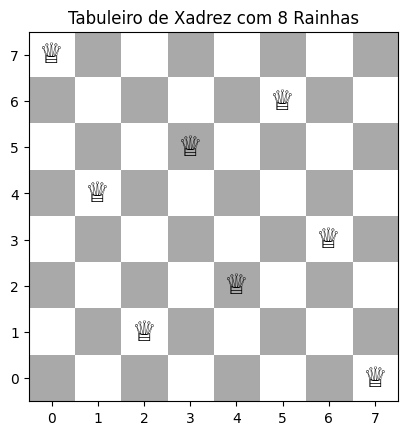

In [ ]:
best_board_ga, best_fitness_ga, generation = running_genetic_algorithm(
    n_queens=8,
    population_size=100,
    max_generations=1000,
    mutation_rate=0.8,
    selection_method="roulette",
    use_elitism=True,
    k_tournament=5
  )

print_board(best_board_ga)

### Cenário 4 - Pressão Seletiva (Roleta vs. Torneio)


Agora, vamos dar foco ao mecanismo de seleção, substituiremos a Roleta pela seleção por Torneio. Ao classificar grupos de k indivíduos e selecionar apenas os mais fortes de cada embate, apresentamos uma pressão competitiva rigorosa, acelerando a convergência em direção a soluções com maiores valores de aptidão.

--- Iniciando GA: Seleção=TOURNAMENT | Mutação=0.1 | Elitismo=False---
Geração 000 | Melhor Fitness atual: 24/28
Geração 050 | Melhor Fitness atual: 27/28
Geração 100 | Melhor Fitness atual: 27/28
Geração 150 | Melhor Fitness atual: 27/28
Geração 200 | Melhor Fitness atual: 27/28
Geração 250 | Melhor Fitness atual: 27/28
Geração 300 | Melhor Fitness atual: 27/28
Solução perfeita (28/28) encontrada na Geração 307!
Indivíduo (Tabuleiro): [5, 2, 6, 1, 7, 4, 0, 3]



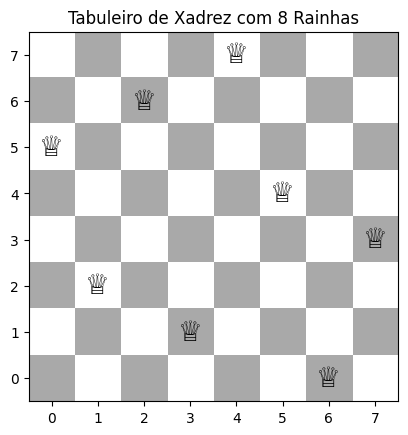

In [ ]:
best_board_ga, best_fitness_ga, generation = running_genetic_algorithm(
    n_queens=8,
    population_size=100,
    max_generations=1000,
    mutation_rate=0.1,
    selection_method="tournament",
    use_elitism=False,
    k_tournament=5
  )

print_board(best_board_ga)

<details>
<summary>Qual o efeito prático da pressão seletiva na diversidade?</summary>

A pressão seletiva determina o grau em que os indivíduos mais aptos são favorecidos na reprodução. Quando a pressão seletiva é alta, os cromossomos dos melhores indivíduos se espalham rapidamente pela população e as linhagens com resultados inferiores acabam morrendo, o que causa uma redução direta na diversidade das soluções observadas. Embora uma forte pressão acelere a convergência da busca, essa rápida perda de diversidade aumenta à medida que as chances de o algoritmo convergir de forma prematura e ficar permanentemente preso em ótimos locais.

</details>

<details>
<summary>O torneio com k=2 seria mais lento que o de k=5?</summary>

Sim, ele seria mais lento. Na seleção por torneio, o parâmetro k atua diretamente como o controlador da pressão seletiva de forma monotônica. O tamanho do torneio afeta probabilisticamente o resultado: ao usar um k maior (como 5), há muito mais chances de sortear os melhores indivíduos da população para a disputa, e consequentemente, muito mais chances de os líderes reproduzirem repetidamente. Isso acelera enormemente a velocidade da convergência (a taxa de "takeover"). Portanto, ao diminuir o torneio para k=2, a pressão seletiva diminui e indivíduos medianos têm mais chance de vencer, o que ajuda a manter a diversidade alta, mas resulta em um avanço mais lento e gradual em direção à solução.

</details>

### Cenário 5 - Comparação exaustiva

Finalmente, realizaremos uma análise comparativa profunda entre todos os experimentos anteriores. O objetivo é avaliar qual conjunto de parâmetros oferece o melhor equilíbrio entre diversidade e velocidade de convergência, identificando a configuração mais eficiente para solucionar o problema das rainhas sob diferentes condições de estresse algorítmico.

In [ ]:
NUM_EXECUCOES = 10
MAX_GERACOES = 1000 # Valor retornado caso fique preso em um máximo local

# Dicionários para armazenar em qual geração a solução foi encontrada em cada execução
resultados = {
    "Cenário 1": [], # Roleta | Mut: 0.1 | Elit: False
    "Cenário 2": [], # Roleta | Mut: 0.5 | Elit: True
    "Cenário 3": [], # Roleta | Mut: 0.5 | Elit: False
    "Cenário 4": []  # Torneio | Mut: 0.1 | Elit: False
}

print(f"Iniciando {NUM_EXECUCOES} execuções para todos os cenários. Isso pode levar alguns minutos...")

for i in range(NUM_EXECUCOES):
    print(f"Progresso: Execução {i+1}/{NUM_EXECUCOES}")

    # Cenário 1: A Busca Sem Rumo
    _, _, gen1 = running_genetic_algorithm(selection_method="roulette", mutation_rate=0.1, use_elitism=False, max_generations=MAX_GERACOES)
    resultados["Cenário 1"].append(gen1)

    # Cenário 2: A Âncora e a Força Bruta
    _, _, gen2 = running_genetic_algorithm(selection_method="roulette", mutation_rate=0.5, use_elitism=True, max_generations=MAX_GERACOES)
    resultados["Cenário 2"].append(gen2)

    # Cenário 3: A Liberdade Caótica
    _, _, gen3 = running_genetic_algorithm(selection_method="roulette", mutation_rate=0.5, use_elitism=False, max_generations=MAX_GERACOES)
    resultados["Cenário 3"].append(gen3)

    # Cenário 4: O Equilíbrio Perfeito
    _, _, gen4 = running_genetic_algorithm(selection_method="tournament", mutation_rate=0.1, use_elitism=False, k_tournament=5, max_generations=MAX_GERACOES)
    resultados["Cenário 4"].append(gen4)

Iniciando 10 execuções para todos os cenários. Isso pode levar alguns minutos...
Progresso: Execução 1/10
--- Iniciando GA: Seleção=ROULETTE | Mutação=0.1 | Elitismo=False---
Geração 000 | Melhor Fitness atual: 25/28
Geração 050 | Melhor Fitness atual: 26/28
Geração 100 | Melhor Fitness atual: 26/28
Geração 150 | Melhor Fitness atual: 25/28
Geração 200 | Melhor Fitness atual: 25/28
Solução perfeita (28/28) encontrada na Geração 205!
Indivíduo (Tabuleiro): [5, 2, 6, 1, 7, 4, 0, 3]

--- Iniciando GA: Seleção=ROULETTE | Mutação=0.5 | Elitismo=True---
Geração 000 | Melhor Fitness atual: 25/28
Geração 050 | Melhor Fitness atual: 26/28
Geração 100 | Melhor Fitness atual: 27/28
Geração 150 | Melhor Fitness atual: 27/28
Geração 200 | Melhor Fitness atual: 27/28
Geração 250 | Melhor Fitness atual: 27/28
Geração 300 | Melhor Fitness atual: 27/28
Solução perfeita (28/28) encontrada na Geração 340!
Indivíduo (Tabuleiro): [3, 1, 7, 5, 0, 2, 4, 6]

--- Iniciando GA: Seleção=ROULETTE | Mutação=0.5 | 

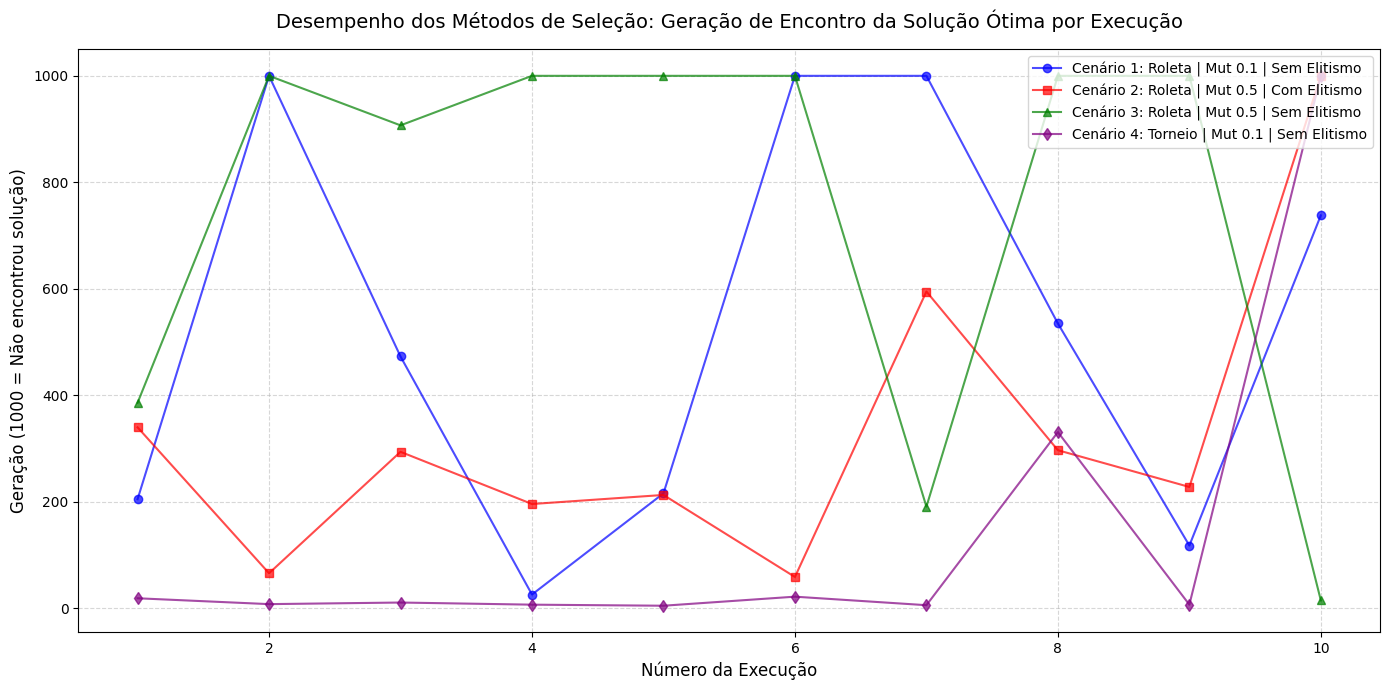

In [ ]:
plt.figure(figsize=(14, 7))

# Eixo X será as múltiplas execuções de 1 a 100
eixo_x = list(range(1, NUM_EXECUCOES + 1))

# Plotando as linhas com pontos (markers) e cores diferentes
plt.plot(eixo_x, resultados["Cenário 1"], marker='o', linestyle='-', color='blue', alpha=0.7, label='Cenário 1: Roleta | Mut 0.1 | Sem Elitismo')
plt.plot(eixo_x, resultados["Cenário 2"], marker='s', linestyle='-', color='red', alpha=0.7, label='Cenário 2: Roleta | Mut 0.5 | Com Elitismo')
plt.plot(eixo_x, resultados["Cenário 3"], marker='^', linestyle='-', color='green', alpha=0.7, label='Cenário 3: Roleta | Mut 0.5 | Sem Elitismo')
plt.plot(eixo_x, resultados["Cenário 4"], marker='d', linestyle='-', color='purple', alpha=0.7, label='Cenário 4: Torneio | Mut 0.1 | Sem Elitismo')

# Configurações de Rótulos e Título
plt.title('Desempenho dos Métodos de Seleção: Geração de Encontro da Solução Ótima por Execução', fontsize=14, pad=15)
plt.xlabel('Número da Execução', fontsize=12)
plt.ylabel('Geração (1000 = Não encontrou solução)', fontsize=12)

# Adicionando legenda e grade para facilitar a leitura
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)

# Evita que o gráfico corte as bordas
plt.tight_layout()

# Exibe o gráfico na tela
plt.show()

## Key Takeways

* **Transição para algoritmos biológicos:** A evolução das estratégias de busca em espaços complexos culmina nos **Algoritmos Genéticos**, inspirados na seleção natural.
* ***Local Beam Search* (Busca em Feixe Local):** Mantém múltiplos estados simultaneamente e compartilha informação entre eles, direcionando a busca para regiões mais promissoras — com risco de perda de diversidade.
* ***Stochastic Beam Search* (Busca em Feixe Estocástica):** Introduz seleção probabilística dos sucessores para preservar diversidade e evitar a concentração prematura da busca.
* **Algoritmos Genéticos:** Estendem a busca em feixe estocástica ao incorporar a metáfora da evolução, permitindo a geração de novas soluções por reprodução.
* **Seleção:** Favorece indivíduos mais aptos na escolha dos pais, utilizando métodos como **Roleta** (proporcional) ou **Torneio** (competitivo).
* **Recombinação:** Combina o material genético de múltiplos indivíduos, permitindo integrar blocos úteis em novas soluções mais eficientes.
* **Mutação:** Introduz variações aleatórias controladas, mantendo a diversidade e reduzindo o risco de convergência em máximos locais.
* **Elitismo:** Preserva os melhores indivíduos entre gerações, garantindo que a aptidão global não diminua ao longo do processo.



## Referências

1. Russell, S. & Norvig, P. (2010). Artificial Intelligence: A Modern Approach. Prentice Hall.
2. GeeksforGeeks: N-Queen Problem using Hill Climbing